In [ ]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

load_dotenv()
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [ ]:
#Chargement
# Chemin absolu vers le fichier
path = "/home/kaouter/Bureau/ubuntu backup/projects/briefs_simplon/briefs/brief6/brief-rfm-louveteaux-sauvages/data/raw/online_retail_II.xlsx"

df = pd.read_excel(path, sheet_name="Year 2010-2011", dtype=str, engine="openpyxl")
print(f"Shape : {df.shape}")
df.head()

Shape : (541910, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [ ]:
#Infos générales
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Invoice      541910 non-null  str  
 1   StockCode    541910 non-null  str  
 2   Description  540456 non-null  str  
 3   Quantity     541910 non-null  str  
 4   InvoiceDate  541910 non-null  str  
 5   Price        541910 non-null  str  
 6   Customer ID  406830 non-null  str  
 7   Country      541910 non-null  str  
dtypes: str(8)
memory usage: 33.1 MB


In [7]:
#Valeurs manquantes
missing = df.isnull().sum().reset_index()
missing.columns = ["colonne", "valeurs_manquantes"]
missing["pourcentage"] = (missing["valeurs_manquantes"] / len(df) * 100).round(2)
missing[missing["valeurs_manquantes"] > 0]

,colonne,valeurs_manquantes,pourcentage
2,Description,1454,0.27
6,Customer ID,135080,24.93


In [8]:
#Doublons
print(f"Lignes dupliquées : {df.duplicated().sum()}")
print(f"Lignes uniques    : {df.drop_duplicates().shape[0]}")

Lignes dupliquées : 5268
Lignes uniques    : 536642


In [9]:
# Cardinalités
for col in df.columns:
    print(f"{col:20s} → {df[col].nunique():>6} valeurs uniques")

Invoice              →  25900 valeurs uniques
StockCode            →   4070 valeurs uniques
Description          →   4223 valeurs uniques
Quantity             →    722 valeurs uniques
InvoiceDate          →  23260 valeurs uniques
Price                →   1630 valeurs uniques
Customer ID          →   4372 valeurs uniques
Country              →     38 valeurs uniques


In [10]:
#Entité : Clients
clients = df[["Customer ID", "Country"]].drop_duplicates()
print(f"Clients uniques : {len(clients)}")
clients["Country"].value_counts().head(10)

Clients uniques : 4389


Country
United Kingdom    3951
Germany             95
France              88
Spain               31
Belgium             25
Switzerland         22
Portugal            20
Italy               15
Finland             12
Austria             11
Name: count, dtype: int64

In [11]:
#Entité : Produits
produits = df[["StockCode", "Description"]].drop_duplicates()
print(f"Produits uniques : {len(produits)}")

# Vérifier si un StockCode peut avoir plusieurs descriptions
produits.groupby("StockCode")["Description"].nunique().sort_values(ascending=False).head(10)

Produits uniques : 5752


StockCode
20713     8
23084     7
21830     6
85175     6
21181     5
72807A    5
23131     5
23343     5
85172     5
82583     4
Name: Description, dtype: int64

In [12]:
#Entité : Factures
factures = df[["Invoice", "Customer ID", "InvoiceDate", "Country"]].drop_duplicates(subset="Invoice")
print(f"Factures uniques : {len(factures)}")

# Retours (invoice commençant par C)
retours = df[df["Invoice"].str.startswith("C")]
print(f"Retours : {len(retours)}")

Factures uniques : 25900
Retours : 9288


In [13]:
#Entité : Lignes de commande
lignes = df[["Invoice", "StockCode", "Quantity", "Price"]]
lignes = lignes.copy()
lignes["Quantity"] = pd.to_numeric(lignes["Quantity"], errors="coerce")
lignes["Price"]    = pd.to_numeric(lignes["Price"],    errors="coerce")
lignes["total_line"] = lignes["Quantity"] * lignes["Price"]

print(f"Lignes de commande : {len(lignes)}")
lignes.describe()

Lignes de commande : 541910


,Quantity,Price,total_line
count,541910.00,541910.00,541910.00
mean,9.55,4.61,17.99
std,218.08,96.76,378.81
min,-80995.00,-11062.06,-168469.60
25%,1.00,1.25,3.40
50%,3.00,2.08,9.75
75%,10.00,4.13,17.40
max,80995.00,38970.00,168469.60


In [14]:
#Modèle relationnel proposé
print("""
Modèle normalisé proposé :
─────────────────────────────────────────────
dim_client
  customer_id  PK
  country

dim_produit
  stock_code   PK
  description

dim_facture
  invoice      PK
  customer_id  FK → dim_client
  invoice_date
  is_retour    BOOLEAN

fact_lignes_commande
  id           PK
  invoice      FK → dim_facture
  stock_code   FK → dim_produit
  quantity
  price
  total_line
─────────────────────────────────────────────
""")


Modèle normalisé proposé :
─────────────────────────────────────────────
dim_client
  customer_id  PK
  country

dim_produit
  stock_code   PK
  description

dim_facture
  invoice      PK
  customer_id  FK → dim_client
  invoice_date
  is_retour    BOOLEAN

fact_lignes_commande
  id           PK
  invoice      FK → dim_facture
  stock_code   FK → dim_produit
  quantity
  price
  total_line
─────────────────────────────────────────────



In [15]:
#Vérification des relations
# Est-ce qu'un client peut avoir plusieurs pays ?
df.groupby("Customer ID")["Country"].nunique().sort_values(ascending=False).head(10)

Customer ID
12370    2
12455    2
12457    2
12417    2
12422    2
12429    2
12431    2
12394    2
16281    1
16282    1
Name: Country, dtype: int64

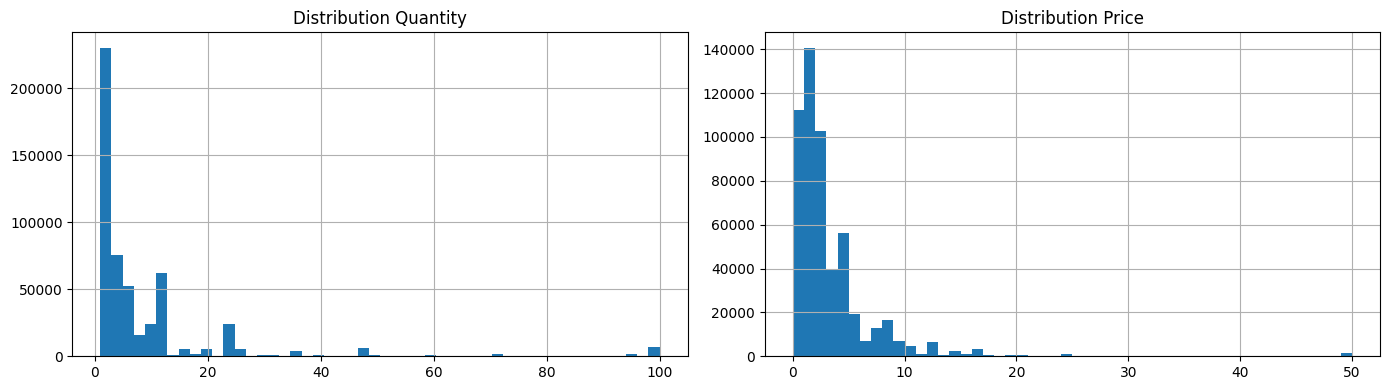

In [16]:
#Distribution des quantités et prix
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"]    = pd.to_numeric(df["Price"],    errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df["Quantity"] > 0]["Quantity"].clip(upper=100).hist(bins=50, ax=axes[0])
axes[0].set_title("Distribution Quantity")

df[df["Price"] > 0]["Price"].clip(upper=50).hist(bins=50, ax=axes[1])
axes[1].set_title("Distribution Price")

plt.tight_layout()
plt.show()

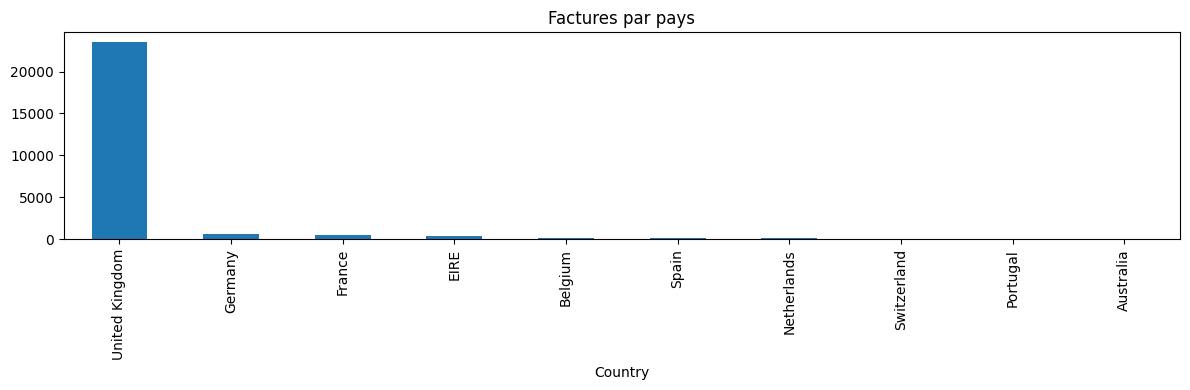

In [17]:
#Transactions par pays
df.groupby("Country")["Invoice"].nunique().sort_values(ascending=False).head(10).plot(
    kind="bar", figsize=(12, 4), title="Factures par pays"
)
plt.tight_layout()
plt.show()